## Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from pyod.utils.data import generate_data
from pyod.models.ocsvm import OCSVM
from pyod.models.deep_svdd import DeepSVDD

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.metrics import balanced_accuracy_score,roc_auc_score, make_scorer
from scipy.io import loadmat

## Helpers

In [3]:
def plot_3d(ax, X, y, title):
    X_in = X[y == 0]
    X_out = X[y == 1]

    ax.scatter(
        X_in[:, 0], X_in[:, 1], X_in[:, 2],
        c='black', marker='o', alpha=1.0, label='inliers'
    )
    ax.scatter(
        X_out[:, 0], X_out[:, 1], X_out[:, 2],
        c='red', marker='o', alpha=1.0, label='outliers'
    )
    
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.set_zlabel("Feature 3")
    ax.legend(loc='best')
    
def plot_four_subplots_3d(X_train, y_train, X_test, y_test,
                          y_train_pred, y_test_pred,
                          suptitle):
    fig = plt.figure(figsize=(14, 10))

    # Ground truth - train
    ax1 = fig.add_subplot(2, 2, 1, projection='3d')
    plot_3d(ax1, X_train, y_train, "GT - Train")

    # Ground truth - test
    ax2 = fig.add_subplot(2, 2, 2, projection='3d')
    plot_3d(ax2, X_test, y_test, "GT - Test")

    # Predicted - train
    ax3 = fig.add_subplot(2, 2, 3, projection='3d')
    plot_3d(ax3, X_train, y_train_pred, "Predicted - Train")

    # Predicted - test
    ax4 = fig.add_subplot(2, 2, 4, projection='3d')
    plot_3d(ax4, X_test, y_test_pred, "Predicted - Test")

    fig.suptitle(suptitle, fontsize=16)
    plt.tight_layout()
    plt.show()

## Ex 1

### Ex 1.1

In [4]:
random_state = 23
n_train = 300
n_test = 200
n_features = 3
contamination = 0.15

X_train, X_test, y_train, y_test = generate_data(
    n_train=n_train,
    n_test=n_test,
    n_features=n_features,
    contamination=contamination,
    random_state=random_state,
)

print("Data shapes:")
print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train (outlier ratio):", y_train.mean())
print("y_test  (outlier ratio):", y_test.mean())

Data shapes:
X_train: (300, 3) X_test: (200, 3)
y_train (outlier ratio): 0.15
y_test  (outlier ratio): 0.15


### Ex 1.2

In [5]:
print("=== OCSVM (linear kernel) ===")

ocsvm_linear = OCSVM(
    kernel='linear',
    nu=contamination,
    contamination=contamination
)
ocsvm_linear.fit(X_train)
y_train_pred_lin = ocsvm_linear.labels_

y_test_pred_lin = ocsvm_linear.predict(X_test)
y_test_scores_lin = ocsvm_linear.decision_function(X_test)

ba_lin = balanced_accuracy_score(y_test, y_test_pred_lin)
roc_lin = roc_auc_score(y_test, y_test_scores_lin)

print(f"Balanced Accuracy : {ba_lin:.6f}")
print(f"ROC AUC           : {roc_lin:.6f}")

=== OCSVM (linear kernel) ===
Balanced Accuracy : 0.991176
ROC AUC           : 1.000000


### Ex 1.3

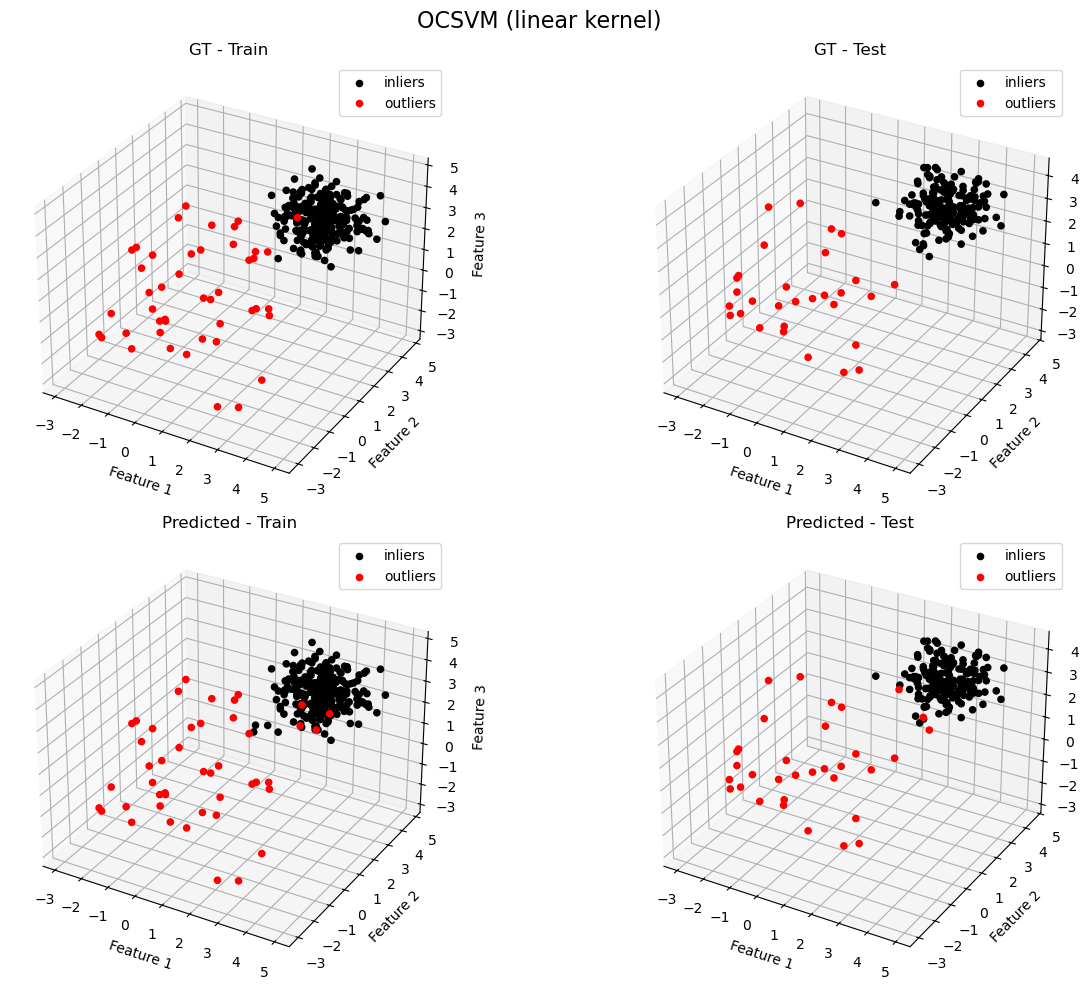

In [6]:
plot_four_subplots_3d(
    X_train, y_train,
    X_test, y_test,
    y_train_pred_lin, y_test_pred_lin,
    suptitle="OCSVM (linear kernel)"
)

### Ex 1.4

=== OCSVM (rbf kernel) ===
Balanced Accuracy : 0.900980
ROC AUC           : 0.983922


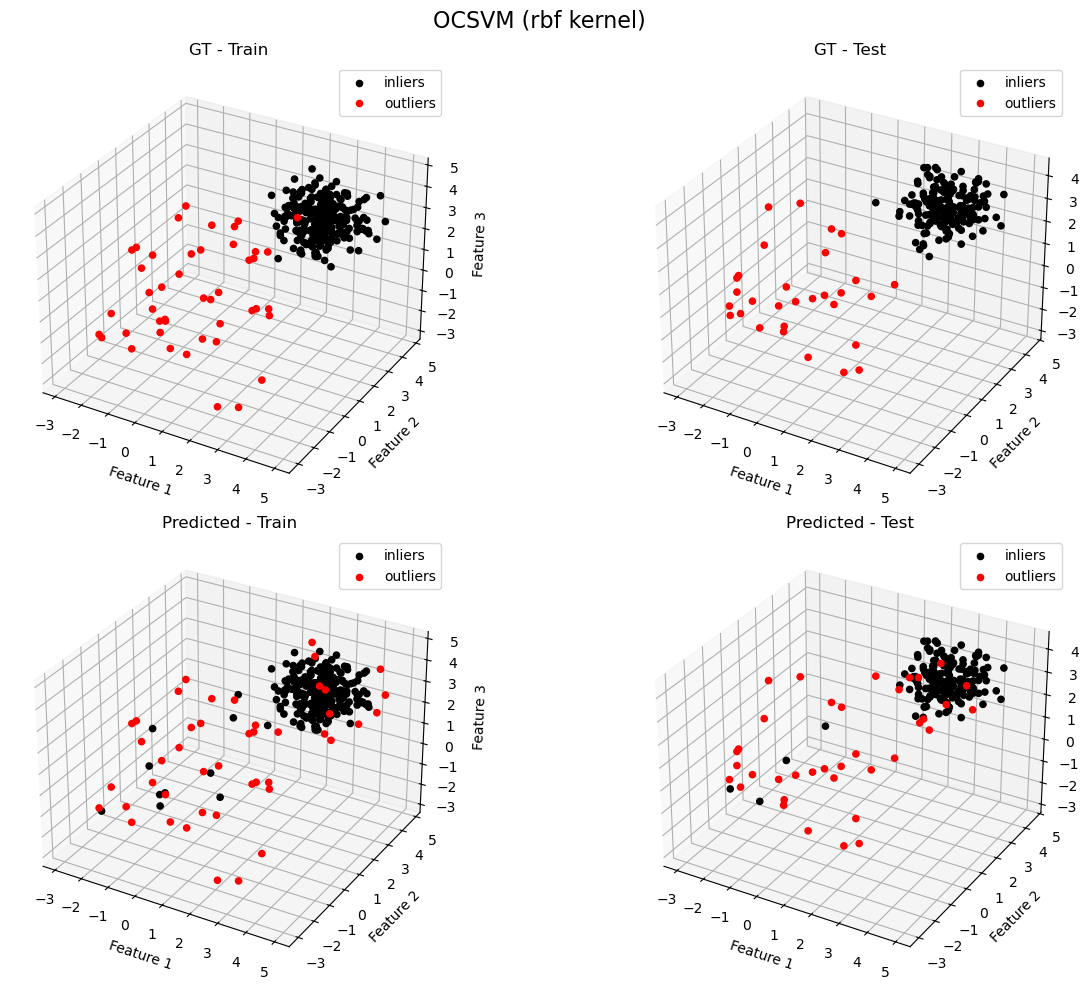

In [7]:
print("=== OCSVM (rbf kernel) ===")

ocsvm_rbf = OCSVM(
    kernel='rbf',
    nu=contamination,
    contamination=contamination
)
ocsvm_rbf.fit(X_train)
y_train_pred_lin = ocsvm_rbf.labels_

y_test_pred_lin = ocsvm_rbf.predict(X_test)
y_test_scores_lin = ocsvm_rbf.decision_function(X_test)

ba_lin = balanced_accuracy_score(y_test, y_test_pred_lin)
roc_lin = roc_auc_score(y_test, y_test_scores_lin)

print(f"Balanced Accuracy : {ba_lin:.6f}")
print(f"ROC AUC           : {roc_lin:.6f}")

plot_four_subplots_3d(
    X_train, y_train,
    X_test, y_test,
    y_train_pred_lin, y_test_pred_lin,
    suptitle="OCSVM (rbf kernel)"
)

### Ex 1.5

=== DeepSVDD ===
Epoch 1/50, Loss: 1.680519700050354
Epoch 2/50, Loss: 1.7356244623661041
Epoch 3/50, Loss: 1.8208644539117813
Epoch 4/50, Loss: 1.9374894350767136
Epoch 5/50, Loss: 1.736846186220646
Epoch 6/50, Loss: 1.923679180443287
Epoch 7/50, Loss: 1.7171538472175598
Epoch 8/50, Loss: 1.7910140976309776
Epoch 9/50, Loss: 1.7744817808270454
Epoch 10/50, Loss: 1.7322938032448292
Epoch 11/50, Loss: 1.6840051338076591
Epoch 12/50, Loss: 1.7442981973290443
Epoch 13/50, Loss: 1.683504544198513
Epoch 14/50, Loss: 1.7910173796117306
Epoch 15/50, Loss: 1.6897734962403774
Epoch 16/50, Loss: 1.7303845137357712
Epoch 17/50, Loss: 1.7623963579535484
Epoch 18/50, Loss: 1.8091139122843742
Epoch 19/50, Loss: 1.9019462130963802
Epoch 20/50, Loss: 1.702361337840557
Epoch 21/50, Loss: 1.7055615484714508
Epoch 22/50, Loss: 1.751696489751339
Epoch 23/50, Loss: 1.7552307322621346
Epoch 24/50, Loss: 1.6639699824154377
Epoch 25/50, Loss: 1.8473233822733164
Epoch 26/50, Loss: 1.8569059893488884
Epoch 27/5

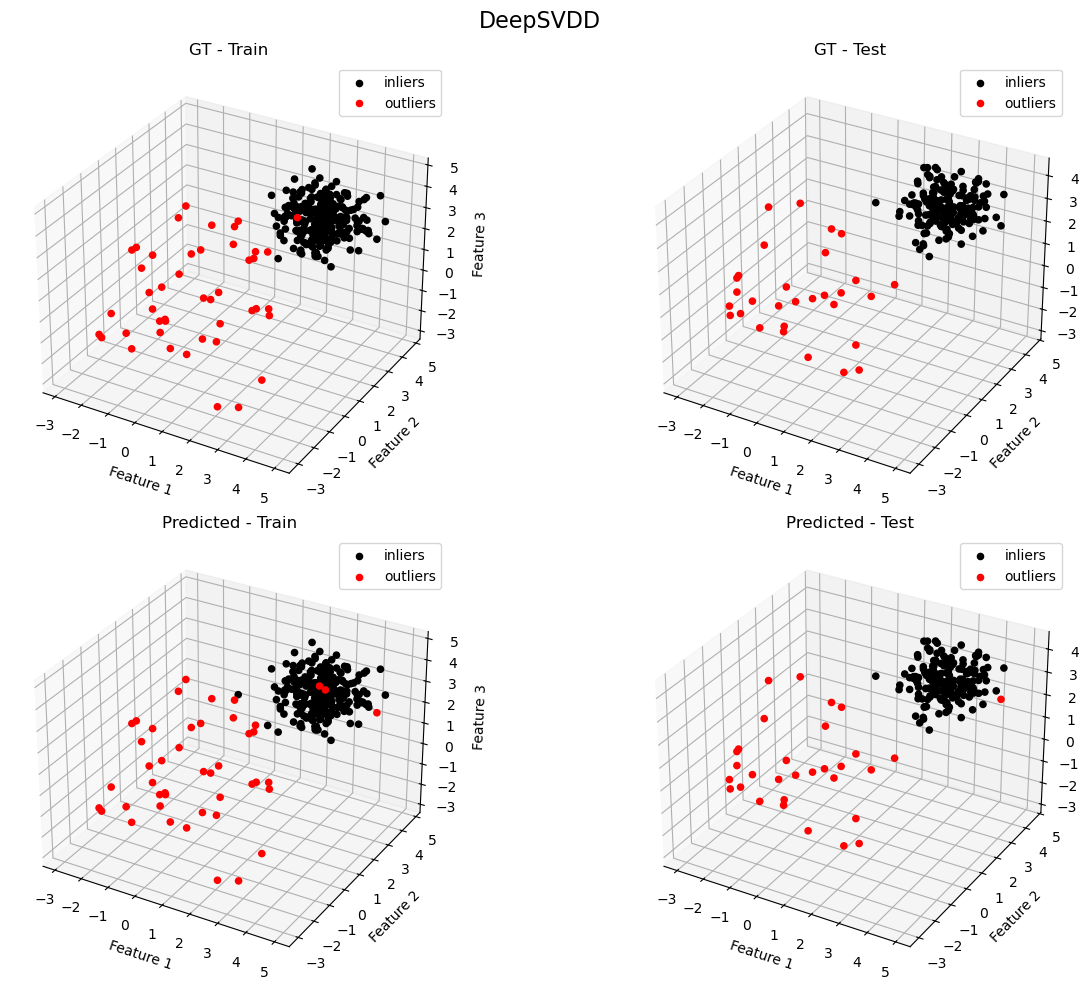

In [14]:
print("=== DeepSVDD ===")

deep_svdd = DeepSVDD(
    n_features=n_features,
    hidden_neurons=[16, 8],
    epochs=50,             
    contamination=contamination,
    verbose=0,
    random_state=23
)

deep_svdd.fit(X_train)

y_train_pred_svdd = deep_svdd.labels_
y_test_pred_svdd = deep_svdd.predict(X_test)
y_test_scores_svdd = deep_svdd.decision_function(X_test)

ba_svdd = balanced_accuracy_score(y_test, y_test_pred_svdd)
roc_svdd = roc_auc_score(y_test, y_test_scores_svdd)

print(f"Balanced Accuracy (DeepSVDD): {ba_svdd:.4f}")
print(f"ROC AUC          (DeepSVDD): {roc_svdd:.4f}")

plot_four_subplots_3d(
    X_train, y_train,
    X_test, y_test,
    y_train_pred_svdd, y_test_pred_svdd,
    suptitle="DeepSVDD"
)

## Ex 2

In [ ]:
data = loadmat("cardio.mat") 

# 1. Load dataset
X = data["X"]
y_pyod = data["y"].ravel().astype(int)

print("Original data shape:", X.shape)
print("Outlier ratio (pyod format, 1 = outlier):", y_pyod.mean())
print()

y = np.where(y_pyod == 0, 1, -1)

# 2. Train/test split (40% train)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.4, random_state=23, stratify=y
)

train_contamination = np.mean(y_train == -1)

# 3. Pipeline: scaler -> OneClassSVM
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("ocsvm", OneClassSVM())
])

# 4. Parameter grid
param_grid = [
    {"ocsvm__kernel": ["linear"], "ocsvm__nu": [train_contamination, 0.08, 0.12, 0.15, 0.18, 0.2]},
    {"ocsvm__kernel": ["rbf", "poly", "sigmoid"],
     "ocsvm__nu": [train_contamination, 0.05, 0.1, 0.2],
     "ocsvm__gamma": [0.001, 0.005, 0.01, 0.02, 0.05, 0.1, "auto", "scale"]},
]

# 5. GridSearchCV using Balanced Accuracy
grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    scoring=make_scorer(balanced_accuracy_score),
    cv=5,
    n_jobs=-1,
    verbose=0
)

grid.fit(X_train, y_train)

# 6. Evaluate best model
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
bal_acc = balanced_accuracy_score(y_test, y_pred)

print()
print("=== Cardio dataset: OCSVM with hyperparameter tuning ===")
print("Best parameters:", grid.best_params_)
print(f"Test Balanced Accuracy: {bal_acc:.8f}")


Original data shape: (1831, 21)
Outlier ratio (pyod format, 1 = outlier): 0.0961223375204806


=== Cardio dataset: OCSVM with hyperparameter tuning ===
Best parameters: {'ocsvm__gamma': 0.001, 'ocsvm__kernel': 'rbf', 'ocsvm__nu': 0.2}
Test Balanced Accuracy: 0.86264702


## Ex 3

In [26]:
def evaluate_pyod_model(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)
    
    if hasattr(model, "decision_function"):
        y_scores = model.decision_function(X_test)
    else:
        y_scores = model.decision_scores_

    ba = balanced_accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_scores)

    print(f"\n=== {model_name} ===")
    print(f"Balanced Accuracy: {ba:.6f}")
    print(f"ROC AUC          : {roc:.6f}")
    return ba, roc

data = loadmat("shuttle.mat") 

X = data["X"]
y = data["y"].ravel().astype(int)   

print("Original data shape:", X.shape)
print("Outlier ratio (pyod, 1 = outlier):", y.mean())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.5,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train outlier ratio:", y_train.mean())
print("Test  outlier ratio:", y_test.mean())

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

train_contamination = y_train.mean()
print("\nEstimated train contamination:", train_contamination)

ocsvm = OCSVM(
    kernel="rbf",
    gamma="auto",             
    nu=train_contamination,
    contamination=train_contamination
)

ocsvm.fit(X_train_scaled)

ba_ocsvm, roc_ocsvm = evaluate_pyod_model(
    ocsvm,
    X_test_scaled,
    y_test,
    model_name="OCSVM"
)

print("\nSummary of results:")
print(f"OCSVM: BA = {ba_ocsvm:.6f}, ROC AUC = {roc_ocsvm:.6f}")

Original data shape: (49097, 9)
Outlier ratio (pyod, 1 = outlier): 0.0715114976475141

Train shape: (24548, 9)  Test shape: (24549, 9)
Train outlier ratio: 0.07149258595404921
Test  outlier ratio: 0.07153040857061388

Estimated train contamination: 0.07149258595404921

=== OCSVM ===
Balanced Accuracy: 0.712645
ROC AUC          : 0.862918

Summary of results:
OCSVM: BA = 0.712645, ROC AUC = 0.862918


In [34]:
architectures = [
    [16, 8],
    [32, 16],
    [64, 32],
    [128, 64],
    [64, 32, 16],
]

results_deepsvdd = []

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

for arch in architectures:
    print(f"Training DeepSVDD with architecture: {arch}")

    deep_svdd = DeepSVDD(
        n_features=X_train_scaled.shape[1],
        hidden_neurons=arch,
        contamination=train_contamination,
        epochs=15,
        verbose=0,
        random_state=23
    )

    deep_svdd.fit(X_train_scaled)

    ba, roc = evaluate_pyod_model(
        deep_svdd,
        X_test_scaled,
        y_test,
        model_name=f"DeepSVDD (hidden_neurons={arch})"
    )
    results_deepsvdd.append((arch, ba, roc))
    

Training DeepSVDD with architecture: [16, 8]
Epoch 1/15, Loss: 201.7591945528984
Epoch 2/15, Loss: 201.40669169649482
Epoch 3/15, Loss: 201.71821933612227
Epoch 4/15, Loss: 201.39893435314298
Epoch 5/15, Loss: 201.41707534715533
Epoch 6/15, Loss: 201.3928254339844
Epoch 7/15, Loss: 201.3994199912995
Epoch 8/15, Loss: 201.40367386303842
Epoch 9/15, Loss: 201.39109144359827
Epoch 10/15, Loss: 201.60231662541628
Epoch 11/15, Loss: 201.42652680166066
Epoch 12/15, Loss: 201.3993965089321
Epoch 13/15, Loss: 201.40134775452316
Epoch 14/15, Loss: 201.48138338699937
Epoch 15/15, Loss: 201.41941659338772

=== DeepSVDD (hidden_neurons=[16, 8]) ===
Balanced Accuracy: 0.978314
ROC AUC          : 0.988058
Training DeepSVDD with architecture: [32, 16]
Epoch 1/15, Loss: 460.69781578332186
Epoch 2/15, Loss: 461.88613222166896
Epoch 3/15, Loss: 460.8185551613569
Epoch 4/15, Loss: 460.89564768224955
Epoch 5/15, Loss: 462.86809128522873
Epoch 6/15, Loss: 461.59349412098527
Epoch 7/15, Loss: 461.3923309314

In [35]:
for arch, ba, roc in results_deepsvdd:
        print(f"DeepSVDD {arch}: BA = {ba:.6f}, ROC AUC = {roc:.6f}")   

DeepSVDD [16, 8]: BA = 0.978314, ROC AUC = 0.988058
DeepSVDD [32, 16]: BA = 0.973253, ROC AUC = 0.988505
DeepSVDD [64, 32]: BA = 0.972530, ROC AUC = 0.989925
DeepSVDD [128, 64]: BA = 0.972859, ROC AUC = 0.989609
DeepSVDD [64, 32, 16]: BA = 0.845720, ROC AUC = 0.976027
